In [1]:
import numpy as np
import pandas as pd

from scipy.interpolate import RBFInterpolator
from scipy.interpolate import PchipInterpolator as Pchip

import pyvista as pv
import matplotlib.pyplot as plt

from pathlib import Path

c:\Miniforge-Data\envs\Data_Analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dimensional analysis in space for Morris Sampling and optimisations. 
Create a space of NRMSE from sampling and responses, and overlays the optimisation path.

In [2]:
def objective_function(npyresult,datafield):

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    rmse=np.sqrt(np.mean((p_interp-p_field)**2))

    return rmse


def normalize_opt_path(opt_df: pd.DataFrame, ranges_dict: dict, name_list: list) -> np.ndarray:
    """
    Normalizes optimization trajectory coordinates to [0, 1] ref using existing ranges_dict bounds.
    """
    norm_coords = []
    
    for col in name_list:
        col_min, col_max = ranges_dict[col]
        norm_col = (opt_df[col] - col_min) / (col_max - col_min)
        norm_coords.append(norm_col.values)
    
    return np.column_stack(norm_coords) # Shape: (N, 3) -> columns [x_norm, y_norm, z_norm]


cwd=Path.cwd()

# Import 

In [3]:
version='v15'
sampling_data_path=Path(f'{cwd}/results_{version}/morris_samples_{version}.csv').resolve()
results_path=Path(f"{cwd}/results_{version}/results/raw_data").resolve()
field_data_path=Path(f"{cwd}/STIMTEC_example/BH10_20180718_40.6_SR_v2.csv")

raw_paths= list((results_path).glob("*.npy"))

file_paths= sorted(
    raw_paths,
    key= lambda p: int(p.stem.split("_")[2])
)

iter_list=[np.load(file,allow_pickle=True).item() for file in file_paths]
sampling_data=pd.read_csv(sampling_data_path,header=0)
field_data=pd.read_csv(field_data_path,header=0)

runname='conf-L-sf0'
runfile='v15_opt5'
opt_path_dir=Path(f"{cwd}/run_{runname}/opt_val_bh10_40_6_run_{runfile}.csv").resolve()
opt_path_data=pd.read_csv(opt_path_dir,header=0)

In [4]:
rsme=[objective_function(iter_,field_data) for iter_ in iter_list]
sampling_data['rmse']=np.array(rsme)
y_range=sampling_data["rmse"].max()-sampling_data["rmse"].min()
sampling_data['nrmse']=(sampling_data['rmse']-sampling_data["rmse"].min())/y_range #0.0 close to best 1.0 penalisation

# Graphing and reducing space

In [5]:
#creating 3D space with selected factors

def nrmse_3d(sampling_data:pd.DataFrame,name_list:list,resolution:int=50,n_splits: int = 5)->None:
    
    #Scale parameters to [0, 1] relative to their min/max bounds
    ranges_dict={}
    for col in name_list:
        col_min = sampling_data[col].min()
        col_max = sampling_data[col].max()
        sampling_data[f'{col}_norm'] = (sampling_data[col] - col_min) / (col_max - col_min)
        ranges_dict[col]=(col_min,col_max)

    new_names=[name+"_b" for name in name_list]

    for new_col,col in zip(new_names,name_list):
        sampling_data[new_col]= sampling_data[f'{col}_norm'].round(2)

    proj_3d=sampling_data.groupby(new_names,as_index=False)['nrmse'].min()

    # normalized coordinates for RBF (pvysta recommeded)
    X_sample = proj_3d[new_names].values
    rmse_sample = proj_3d['nrmse'].values

    eps=0.5
    rbf = RBFInterpolator(
        X_sample, 
        rmse_sample, 
        kernel= 'thin_plate_spline',
        epsilon=eps,
        smoothing = 1e-1 
        )

    grid_res = 50  # 50x50x50 voxels
    x_range = np.linspace(X_sample[:, 0].min(), X_sample[:, 0].max(), grid_res)
    y_range = np.linspace(X_sample[:, 1].min(), X_sample[:, 1].max(), grid_res)
    z_range = np.linspace(X_sample[:, 2].min(), X_sample[:, 2].max(), grid_res)

    grid_x, grid_y, grid_z = np.meshgrid(x_range, y_range, z_range, indexing='ij')
    eval_pts = np.column_stack([grid_x.ravel(), grid_y.ravel(), grid_z.ravel()])

    grid_rmse = rbf(eval_pts)

    grid = pv.StructuredGrid(grid_x, grid_y, grid_z)
    grid.point_data["NRMSE"] = grid_rmse.ravel()

    fitting= interpolator_fitting(
        # interpolator= rbf,
        x_array=X_sample,
        rmse_sample= rmse_sample,
        n_splits=n_splits
        )
    
    return grid_rmse,grid,ranges_dict,proj_3d, rmse_sample, fitting

# def interpolator_fitting(
#     x_array: np.ndarray,
#     rmse_sample: np.ndarray,
#     n_splits: int = 5
# ) -> plt.Figure:

#     from sklearn.gaussian_process import GaussianProcessRegressor
#     from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
#     from sklearn.model_selection import KFold
#     from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
#     oof_predictions = np.zeros_like(rmse_sample)
#     fold_rmses = []
    
#     n_features = x_array.shape[1] if x_array.ndim > 1 else 1

#     for train_idx, test_idx in kf.split(x_array):
#         X_tr, y_tr = x_array[train_idx], rmse_sample[train_idx]
#         X_te, y_te = x_array[test_idx], rmse_sample[test_idx]

#         kernel = C(1.0, (1e-6, 1e6)) * Matern(
#             length_scale= np.ones(n_features),
#             length_scale_bounds=(1e-4,1e5),
#             nu=2.5,
#         ) + WhiteKernel(noise_level=1e-4, noise_level_bounds= (1e-8, 1e2))

#         gpr= GaussianProcessRegressor(
#             kernel= kernel,
#             n_restarts_optimizer=10,
#             alpha=1e-6,
#             random_state=42
#         )

#         gpr_fold = GaussianProcessRegressor(
#             kernel=kernel,
#             n_restarts_optimizer=10,
#             alpha=1e-6,
#             random_state=42
#         )

#         gpr_fold.fit(X_tr, y_tr)
#         preds = gpr_fold.predict(X_te)
        
#         oof_predictions[test_idx] = preds
#         fold_rmses.append(np.sqrt(mean_squared_error(y_te, preds)))

#     # Compute Out-of-Fold overall metrics
#     r2_oof = r2_score(rmse_sample, oof_predictions)
#     mae_oof = mean_absolute_error(rmse_sample, oof_predictions)
#     rmse_oof = np.sqrt(mean_squared_error(rmse_sample, oof_predictions))

#     print(f"=== {n_splits}-Fold Cross-Validation Diagnostics GPR anysotropic===")
#     print(f"Mean Fold RMSE:            {np.mean(fold_rmses):.6f} (± {np.std(fold_rmses):.6f})")
#     print(f"Overall OOF R² Score:      {r2_oof:.4f}")
#     print(f"Overall OOF MAE:           {mae_oof:.6f}")
#     print(f"Overall OOF RMSE:          {rmse_oof:.6f}")

#     # Plot Out-of-Fold 1:1 validation scatter
#     fig, ax = plt.subplots(figsize=(6, 6))

#     ax.scatter(rmse_sample, oof_predictions, alpha=0.6, color='teal', edgecolor='k', label='Out-of-Fold Test Points')
#     ax.plot(
#         [rmse_sample.min(), rmse_sample.max()], 
#         [rmse_sample.min(), rmse_sample.max()], 
#         'r--', label='1:1 Perfect Fit'
#     )

#     ax.set_xlabel('Observed Min NRMSE')
#     ax.set_ylabel('Cross-Validated Interpolated NRMSE')
#     ax.set_title(f'GPR K-Fold Cross-Validation Accuracy (R² = {r2_oof:.3f})')
#     ax.grid(True, linestyle=':', alpha=0.6)
#     ax.legend()
#     fig.tight_layout()

#     return fig
       
def interpolator_fitting(
    x_array: np.ndarray,
    rmse_sample: np.ndarray,
    n_splits: int = 5
) -> plt.Figure:

    from sklearn.model_selection import KFold
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_predictions = np.zeros_like(rmse_sample)
    fold_rmses = []
    
    # K-Fold loop to test true interpolation error on unseen folds
    for train_idx, test_idx in kf.split(x_array):
        X_tr, y_tr = x_array[train_idx], rmse_sample[train_idx]
        X_te, y_te = x_array[test_idx], rmse_sample[test_idx]

        rbf_fold = RBFInterpolator(
            X_tr,
            y_tr,
            kernel='thin_plate_spline',
            epsilon = 0.5,
            smoothing=1e-1)
        preds = rbf_fold(X_te)
        
        oof_predictions[test_idx] = preds
        fold_rmses.append(np.sqrt(mean_squared_error(y_te, preds)))

    # Compute Out-of-Fold overall metrics
    r2_oof = r2_score(rmse_sample, oof_predictions)
    mae_oof = mean_absolute_error(rmse_sample, oof_predictions)
    rmse_oof = np.sqrt(mean_squared_error(rmse_sample, oof_predictions))

    print(f"=== {n_splits}-Fold Cross-Validation Diagnostics ===")
    print(f"Mean Fold RMSE:            {np.mean(fold_rmses):.6f} (± {np.std(fold_rmses):.6f})")
    print(f"Overall OOF R² Score:      {r2_oof:.4f}")
    print(f"Overall OOF MAE:           {mae_oof:.6f}")
    print(f"Overall OOF RMSE:          {rmse_oof:.6f}")

    # Plot Out-of-Fold 1:1 validation scatter
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(rmse_sample, oof_predictions, alpha=0.6, color='teal', edgecolor='k', label='Out-of-Fold Test Points')
    ax.plot(
        [rmse_sample.min(), rmse_sample.max()], 
        [rmse_sample.min(), rmse_sample.max()], 
        'r--', label='1:1 Perfect Fit'
    )

    ax.set_xlabel('Observed Min NRMSE')
    ax.set_ylabel('Cross-Validated Interpolated NRMSE')
    ax.set_title(f'K-Fold Cross-Validation Accuracy (R² = {r2_oof:.3f})')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    fig.tight_layout()

    return fig
    

def plot_3d_nrmse(grid:pv.StructuredGrid,rmse_sample,levels:list,ranges_dict:dict) -> pv.Plotter:
    
    target_levels = [float(np.quantile(rmse_sample, level)) for level in levels
    ]

    plotter = pv.Plotter(window_size=[1024, 768])
    plotter.set_background("white")

    colors = ["tab:blue",
         "tab:orange",
         "tab:green",
         "tab:red",
         "tab:purple",
         "tab:brown",
         "tab:pink",
         "tab:gray",
         "tab:olive",
         "tab:cyan"
    ]
    opacities = [0.8,0.8,0.6,0.6,0.4,0.4,0.3,0.3,0.2]

    for i, level in enumerate(target_levels):
          # Extract single surface shell
          single_shell = grid.contour(isosurfaces=[level], scalars="NRMSE")
          shell_color= colors[i % len(colors)]

          plotter.add_mesh(
               single_shell,
               color=shell_color,
               opacity=opacities[i % len(opacities)],
               smooth_shading=True,
               label=f"NRMSE = {level:.3f}"
          )

     # Add legend to explain each discrete color shell
    plotter.add_legend(bcolor="white", border=True,loc='center right')
    
    plotter.show_bounds(
    xtitle="pjack",
    ytitle="wr",
    ztitle="L",
    grid='back',
    location='outer',
    ticks='outside',
    color='black'
     )

    plotter.add_axes()

    return plotter

def axis_rescale(plotter: pv.Plotter, ranges_dict: dict, name_list: list) -> pv.Plotter:
    plotter.set_scale(xscale=1.0, yscale=1.0, zscale=1.0)
    
    x_min, x_max = ranges_dict[name_list[0]]
    y_min, y_max = ranges_dict[name_list[1]]
    z_min, z_max = ranges_dict[name_list[2]]
    
    x_title = f"{name_list[0]} [{x_min:.1e} to {x_max:.1e}] Pa"
    y_title = f"{name_list[1]} [{y_min:.1e} to {y_max:.1e}] Pa"
    z_title = f"{name_list[2]} [{z_min:.1e} to {z_max:.1e}] Pa^-1" 
    
    plotter.show_bounds(
        xtitle=x_title,
        ytitle=y_title,
        ztitle=z_title,
        grid='back',
        location='outer',
        ticks='outside',
        color='black'
    )
    
    return plotter

def add_optimization_path(
    plotter: pv.Plotter, 
    path_coords: np.ndarray, 
    nrmse_values: np.ndarray,
    line_color: str = "black",
    point_color: str = "red",
    tube_radius: float = 0.008,
    show_labels: bool = True
) -> pv.Plotter:
    """
    Overlays a 3D optimization trajectory onto an existing PyVista plotter.
    
    Parameters:
    plotter : pv.Plotter
        The active PyVista plotter object.
    path_coords : np.ndarray
        Normalized (N, 3) coordinates [0, 1] of the optimization steps.
    nrmse_values : np.ndarray
        Array of NRMSE loss values for each iteration.
    """
  
    points = pv.PolyData(path_coords)
    
    n_points = len(path_coords)
    # VTK line connectivity format: [number_of_pts_in_line, pt0, pt1, pt2, ...]
    lines = np.hstack([[n_points], np.arange(n_points)])
    points.lines = lines

    tube = points.tube(radius=tube_radius)
    
    plotter.add_mesh(
        tube, 
        color=line_color, 
        scalars=None,
        smooth_shading=True, 
        label="Optimization Path"
    )

    plotter.add_mesh(
        points, 
        color=point_color, 
        scalars=None,
        point_size=12, 
        render_points_as_spheres=True,
        label="Evaluated Steps"
    )

    if show_labels:
        labels = [f"#{i}: {val:.3f}" for i, val in enumerate(nrmse_values)]
        
        plotter.add_point_labels(
            points,
            labels,
            font_size=12,
            text_color="black",
            point_color=point_color,
            point_size=8,
            shape_color="white",
            shape_opacity=0.85,
            always_visible=True  # Keeps labels visible through isosurface transparency
        )

    return plotter

=== 5-Fold Cross-Validation Diagnostics ===
Mean Fold RMSE:            0.249015 (± 0.046169)
Overall OOF R² Score:      0.2456
Overall OOF MAE:           0.209949
Overall OOF RMSE:          0.252696


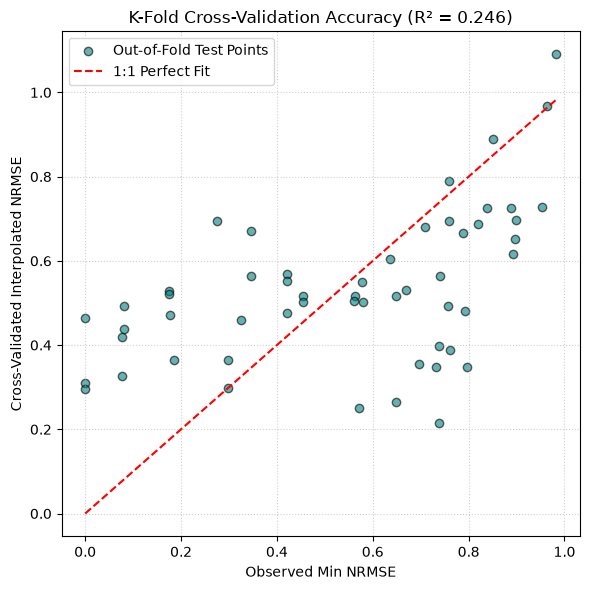

In [6]:
name_list=['pjack', 'wr', 'L']
grid_rmse, grid, ranges_dict, proj_3d, rmse_sample,fit= nrmse_3d(sampling_data,name_list)

# fit.savefig("intepolator_fitting_BH10_40_6_opt5_v15.pdf", format="pdf",
#                 bbox_inches='tight',
#                 pad_inches=0.05
#             )

In [7]:

opt_path_norm= normalize_opt_path(opt_path_data,ranges_dict,name_list)

In [8]:
opt_nrmse=[]   
min_cost_opt=opt_path_data['cost'].min()
for col,keyword  in opt_path_data.iterrows(): 
    opt_n=(keyword['cost']-min_cost_opt)/y_range
    opt_nrmse.append(opt_n)
opt_nrmse=np.array(opt_nrmse)
        


In [9]:
#optional saving the normalised data to be projected
# proj_3d.to_csv("3D_projected_nrmse_bh10_40_6_v15.csv", index=False)

C:\Users\penack5q\AppData\Local\Temp\ipykernel_23416\2027616841.py:18: UserWarning: Failed to use notebook backend "trame": Please install `ipywidgets`.

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  fig_3d.show()


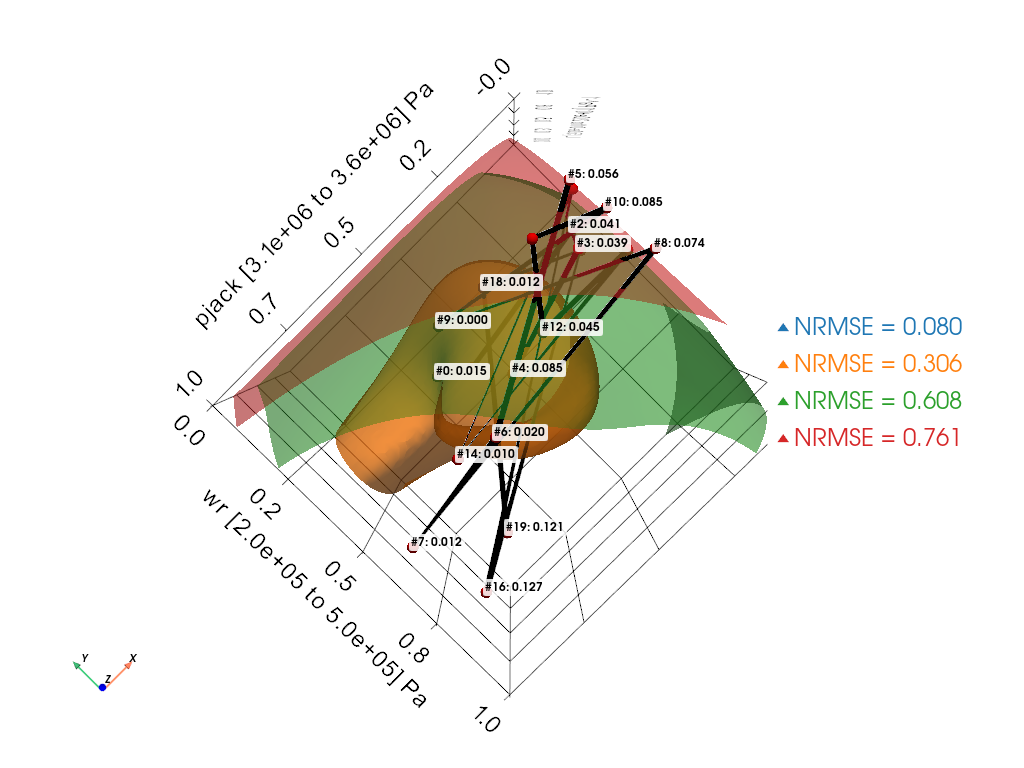

In [ ]:
levels=[0.10,0.25,0.50,0.75]
fig_3d= plot_3d_nrmse(grid, rmse_sample,levels,ranges_dict)

fig_3d=axis_rescale(fig_3d,ranges_dict,name_list)

fig_3d = add_optimization_path(
    fig_3d, 
    path_coords=opt_path_norm, 
    nrmse_values=opt_nrmse,
    line_color="black",
    point_color="red"
)

fig_3d.reset_camera()
# fig_3d.camera.azimuth = 0
# fig_3d.camera.elevation = 60
fig_3d.camera.zoom(0.85)
fig_3d.show()
# fig_3d.screenshot("nmrse3d_BH10_40_6_opt5_v15.png", transparent_background=True) #background can be mate also or solid
# fig_3d.export_html("nmrse3d_BH10_40_6_opt5_v15.html")
